# Phase 1 — Small Model Baseline

**Goal:** Establish baseline performance for financial sentiment classification using:
1. Zero-shot `distilbert-base-uncased` (random 3-class head — untrained baseline)
2. Zero-shot `ProsusAI/finbert` (pre-trained financial sentiment — strong baseline)
3. Fine-tuned `distilbert-base-uncased` on our training split

**Per-example outputs:** predicted label, class probabilities, confidence, entropy, margin

---

## 1. Install Dependencies

In [1]:
%%capture
!pip install -q transformers datasets accelerate scikit-learn seaborn matplotlib

In [11]:
!pip install -U pip
!pip install pandas numpy torch scikit-learn matplotlib seaborn tqdm transformers datasets accelerate
!pip install python-dotenv

## 2. Mount Google Drive & Configure Paths

In [15]:
# from google.colab import drive
# import os

# drive.mount('/content/drive', force_remount=False)

# PROJECT_DIR = '/content/drive/MyDrive/CSCI 5541 Project'
# DATA_DIR    = os.path.join(PROJECT_DIR, 'processed_data')
# MODEL_DIR   = os.path.join(PROJECT_DIR, 'models')
# FIG_DIR     = os.path.join(DATA_DIR, 'eda_figures')

# os.makedirs(MODEL_DIR, exist_ok=True)
# os.makedirs(FIG_DIR, exist_ok=True)

# print(f'Data dir:  {DATA_DIR}')
# print(f'Model dir: {MODEL_DIR}')
# print(f'Fig dir:   {FIG_DIR}')

# assert os.path.isdir(PROJECT_DIR), 'PROJECT_DIR shortcut not found in Drive.'

import os
from dotenv import load_dotenv

load_dotenv()  # reads .env from current working dir

PROJECT_DIR = os.getenv("PROJECT_DIR")
if not PROJECT_DIR:
    raise ValueError("PROJECT_DIR missing in .env")

DATA_DIR  = os.path.join(PROJECT_DIR, "data/processed_data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
FIG_DIR   = os.path.join(PROJECT_DIR, "Output/model_outputs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Data dir:  {DATA_DIR}")
print(f"Model dir: {MODEL_DIR}")
print(f"Fig dir:   {FIG_DIR}")

Data dir:  /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/processed_data
Model dir: /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/models
Fig dir:   /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/model_outputs


## 3. Load Data

In [16]:
import pandas as pd
import numpy as np

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_NAMES = ['negative', 'neutral', 'positive']

print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')
print(f'Label distribution (train):\n{df_train["label"].value_counts()}')

Train: 2413  Val: 517  Test: 518
Label distribution (train):
label
neutral     1498
positive     621
negative     294
Name: count, dtype: int64


## 4. Helper Functions

In [17]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


class SentenceDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len=128):
        self.encodings = tokenizer(
            sentences, truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}


def compute_predictions(model, tokenizer, df, label2id, id2label,
                        batch_size=32, max_len=128):
    """Run inference and return df augmented with prediction columns."""
    model.eval()
    model.to(DEVICE)

    sentences = df['sentence'].tolist()
    dataset = SentenceDataset(sentences, tokenizer, max_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Inference'):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.concatenate(all_probs, axis=0)  # (N, 3)

    pred_ids = np.argmax(all_probs, axis=1)
    pred_labels = [id2label[i] for i in pred_ids]

    confidence = np.max(all_probs, axis=1)

    eps = 1e-12
    entropy = -np.sum(all_probs * np.log(all_probs + eps), axis=1)

    sorted_probs = np.sort(all_probs, axis=1)[:, ::-1]
    margin = sorted_probs[:, 0] - sorted_probs[:, 1]

    result = df[['id', 'sentence', 'label']].copy()
    result.rename(columns={'label': 'true_label'}, inplace=True)
    result['predicted_label'] = pred_labels
    result['prob_negative'] = all_probs[:, label2id['negative']]
    result['prob_neutral']  = all_probs[:, label2id['neutral']]
    result['prob_positive'] = all_probs[:, label2id['positive']]
    result['confidence'] = confidence
    result['entropy'] = entropy
    result['margin'] = margin

    return result


def evaluate_and_report(df_preds, title='', save_cm_path=None):
    """Print classification metrics and optionally save confusion matrix."""
    y_true = df_preds['true_label']
    y_pred = df_preds['predicted_label']

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', labels=LABEL_NAMES)

    print(f'\n{"=" * 60}')
    if title:
        print(f'  {title}')
    print(f'{"=" * 60}')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Macro-F1:  {macro_f1:.4f}')
    print(f'\nPer-class report:')
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=LABEL_NAMES)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title or 'Confusion Matrix')
    plt.tight_layout()
    if save_cm_path:
        fig.savefig(save_cm_path, dpi=150, bbox_inches='tight')
        print(f'Confusion matrix saved to {save_cm_path}')
    plt.show()

    return {'accuracy': acc, 'macro_f1': macro_f1}

Using device: cpu


/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 5. Baseline 1 — Zero-Shot DistilBERT (untrained 3-class head)

`distilbert-base-uncased` with a randomly-initialized 3-class classification head.  
This represents true zero-shot (no fine-tuning) performance.

In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

distilbert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_zeroshot = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
print('Loaded distilbert-base-uncased with random 3-class head')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10358.35it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded distilbert-base-uncased with random 3-class head


Inference: 100%|██████████| 17/17 [00:08<00:00,  2.10it/s]
/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pred


  Baseline 1: Zero-Shot DistilBERT — Test Set
Accuracy:  0.2239
Macro-F1:  0.1732

Per-class report:
              precision    recall  f1-score   support

    negative     0.1186    0.7778    0.2059        63
     neutral     0.6381    0.2081    0.3138       322
    positive     0.0000    0.0000    0.0000       133

    accuracy                         0.2239       518
   macro avg     0.2522    0.3286    0.1732       518
weighted avg     0.4111    0.2239    0.2201       518



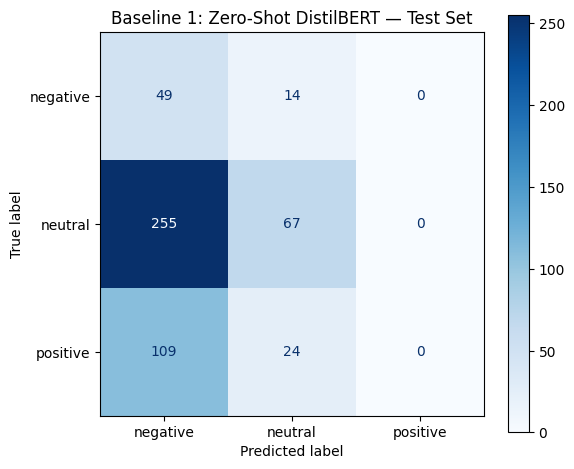


Saved baseline_distilbert_test_predictions.csv


,id,sentence,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence,entropy,margin
0,2033,Lemmink+ñinen started the manufacture of roofi...,neutral,neutral,0.347327,0.354520,0.298154,0.354520,1.095738,0.007193
1,2602,OP-Pohjola Group 's capital adequacy ratio und...,neutral,negative,0.353220,0.350599,0.296181,0.353220,1.095439,0.002622
2,124,Also Lemmink+ñinen 's profit for accounting pe...,positive,neutral,0.353811,0.358503,0.287685,0.358503,1.093790,0.004692
3,2306,The reductions will be implemented mainly in t...,neutral,negative,0.366078,0.348838,0.285084,0.366078,1.093025,0.017240
4,2590,No planned closing date was provided .,neutral,negative,0.365578,0.353683,0.280739,0.365578,1.092105,0.011895


In [19]:
distilbert_zs_test = compute_predictions(
    distilbert_zeroshot, distilbert_tokenizer, df_test,
    LABEL2ID, ID2LABEL
)

distilbert_zs_metrics = evaluate_and_report(
    distilbert_zs_test,
    title='Baseline 1: Zero-Shot DistilBERT — Test Set'
)

distilbert_zs_test.to_csv(
    os.path.join(DATA_DIR, 'baseline_distilbert_test_predictions.csv'),
    index=False
)
print('\nSaved baseline_distilbert_test_predictions.csv')
distilbert_zs_test.head()

In [20]:
del distilbert_zeroshot
torch.cuda.empty_cache()

---
## 6. Baseline 2 — Zero-Shot FinBERT (`ProsusAI/finbert`)

FinBERT is pre-trained on financial text and fine-tuned for 3-class sentiment.  
Native label mapping: `{positive: 0, negative: 1, neutral: 2}` — remapped to ours.

In [21]:
finbert_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
finbert_model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')

finbert_native_id2label = finbert_model.config.id2label
print(f'FinBERT native labels: {finbert_native_id2label}')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 36223.04it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT native labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


FinBERT index map: {'positive': 0, 'negative': 1, 'neutral': 2}


FinBERT inference: 100%|██████████| 17/17 [00:17<00:00,  1.02s/it]


  Baseline 2: Zero-Shot FinBERT — Test Set
Accuracy:  0.9459
Macro-F1:  0.9346

Per-class report:
              precision    recall  f1-score   support

    negative     0.8732    0.9841    0.9254        63
     neutral     0.9967    0.9348    0.9647       322
    positive     0.8759    0.9549    0.9137       133

    accuracy                         0.9459       518
   macro avg     0.9153    0.9579    0.9346       518
weighted avg     0.9507    0.9459    0.9468       518



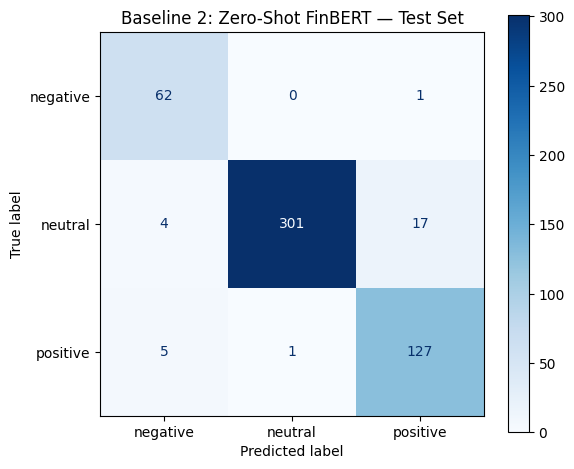


Saved baseline_finbert_test_predictions.csv


,id,sentence,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence,entropy,margin
0,2033,Lemmink+ñinen started the manufacture of roofi...,neutral,neutral,0.021143,0.936909,0.041948,0.936909,0.275625,0.894961
1,2602,OP-Pohjola Group 's capital adequacy ratio und...,neutral,neutral,0.033310,0.929954,0.036736,0.929954,0.302225,0.893219
2,124,Also Lemmink+ñinen 's profit for accounting pe...,positive,positive,0.024318,0.023318,0.952364,0.952364,0.224503,0.928047
3,2306,The reductions will be implemented mainly in t...,neutral,neutral,0.081428,0.822653,0.095919,0.822653,0.589681,0.726734
4,2590,No planned closing date was provided .,neutral,neutral,0.037946,0.942455,0.019599,0.942455,0.257071,0.904508


In [22]:
# FinBERT's label order: {0: 'positive', 1: 'negative', 2: 'neutral'}
# We need to remap columns so prob_negative/neutral/positive are correct.

FINBERT_IDX = {
    name.lower(): idx
    for idx, name in finbert_model.config.id2label.items()
}
print(f'FinBERT index map: {FINBERT_IDX}')


def compute_predictions_finbert(model, tokenizer, df, batch_size=32, max_len=128):
    """FinBERT-specific inference with label remapping."""
    model.eval()
    model.to(DEVICE)

    sentences = df['sentence'].tolist()
    dataset = SentenceDataset(sentences, tokenizer, max_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='FinBERT inference'):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.concatenate(all_probs, axis=0)  # (N, 3) in FinBERT order

    # Remap to our convention: [negative, neutral, positive]
    remapped = np.zeros_like(all_probs)
    remapped[:, LABEL2ID['negative']] = all_probs[:, FINBERT_IDX['negative']]
    remapped[:, LABEL2ID['neutral']]  = all_probs[:, FINBERT_IDX['neutral']]
    remapped[:, LABEL2ID['positive']] = all_probs[:, FINBERT_IDX['positive']]

    pred_ids = np.argmax(remapped, axis=1)
    pred_labels = [ID2LABEL[i] for i in pred_ids]

    confidence = np.max(remapped, axis=1)

    eps = 1e-12
    entropy = -np.sum(remapped * np.log(remapped + eps), axis=1)

    sorted_probs = np.sort(remapped, axis=1)[:, ::-1]
    margin = sorted_probs[:, 0] - sorted_probs[:, 1]

    result = df[['id', 'sentence', 'label']].copy()
    result.rename(columns={'label': 'true_label'}, inplace=True)
    result['predicted_label'] = pred_labels
    result['prob_negative'] = remapped[:, LABEL2ID['negative']]
    result['prob_neutral']  = remapped[:, LABEL2ID['neutral']]
    result['prob_positive'] = remapped[:, LABEL2ID['positive']]
    result['confidence'] = confidence
    result['entropy'] = entropy
    result['margin'] = margin

    return result


finbert_test = compute_predictions_finbert(
    finbert_model, finbert_tokenizer, df_test
)

finbert_metrics = evaluate_and_report(
    finbert_test,
    title='Baseline 2: Zero-Shot FinBERT — Test Set'
)

finbert_test.to_csv(
    os.path.join(DATA_DIR, 'baseline_finbert_test_predictions.csv'),
    index=False
)
print('\nSaved baseline_finbert_test_predictions.csv')
finbert_test.head()

In [23]:
del finbert_model
torch.cuda.empty_cache()

---
## 7. Fine-Tune DistilBERT on Training Split

Fine-tune `distilbert-base-uncased` with a 3-class head on `train.csv`.  
Evaluate on `val.csv` each epoch; select best checkpoint by macro-F1.

In [24]:
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
import json

SEED = 5541
MAX_LEN = 128
BATCH_SIZE = 16
LR = 2e-5
EPOCHS = 5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
PATIENCE = 2

ft_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
ft_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)


def tokenize_df(df, tokenizer, max_len=MAX_LEN):
    hf = HFDataset.from_pandas(df[['sentence', 'label']].copy())
    hf = hf.map(lambda x: {'labels': LABEL2ID[x['label']]})
    hf = hf.map(
        lambda x: tokenizer(x['sentence'], truncation=True, padding='max_length', max_length=max_len),
        batched=True
    )
    hf.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    return hf


train_ds = tokenize_df(df_train, ft_tokenizer)
val_ds   = tokenize_df(df_val,   ft_tokenizer)

print(f'Train dataset: {len(train_ds)}  Val dataset: {len(val_ds)}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7579.84it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 517/517 [00:00<00:00, 14060.70 examples/s]

Train dataset: 2413  Val dataset: 517


In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro')
    return {'accuracy': acc, 'f1': macro_f1}


CHECKPOINT_DIR = os.path.join(MODEL_DIR, 'finetuned_distilbert_baseline', 'checkpoints')

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_total_limit=2,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

print('Starting fine-tuning...')
train_result = trainer.train()
print(f'\nTraining complete. Best metric: {trainer.state.best_metric:.4f}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning...


/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.670865,0.329812,0.880077,0.828692
2,0.198536,0.258237,0.905222,0.873384
3,0.104117,0.345457,0.914894,0.877346
4,0.060152,0.363541,0.911025,0.887105
5,0.034547,0.349805,0.920696,0.897629


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.37it/s]
/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]
/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.16it/s]
/Users/tejeshwinirs/Documents/Projects/UMN/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model


Training complete. Best metric: 0.8976


---
## 8. Evaluate Fine-Tuned Model

Report accuracy, macro-F1, per-class P/R/F1, and confusion matrix on **validation** and **test** sets.

Inference: 100%|██████████| 17/17 [00:09<00:00,  1.76it/s]



  Fine-Tuned DistilBERT — Validation Set
Accuracy:  0.9207
Macro-F1:  0.8976

Per-class report:
              precision    recall  f1-score   support

    negative     0.9000    0.8571    0.8780        63
     neutral     0.9505    0.9564    0.9534       321
    positive     0.8582    0.8647    0.8614       133

    accuracy                         0.9207       517
   macro avg     0.9029    0.8927    0.8976       517
weighted avg     0.9206    0.9207    0.9206       517

Confusion matrix saved to /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/model_outputs/confusion_matrix_val.png


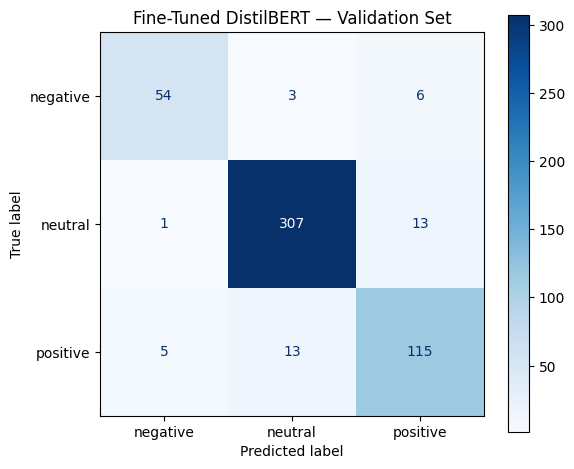

In [26]:
ft_val_preds = compute_predictions(
    trainer.model, ft_tokenizer, df_val, LABEL2ID, ID2LABEL
)

ft_val_metrics = evaluate_and_report(
    ft_val_preds,
    title='Fine-Tuned DistilBERT — Validation Set',
    save_cm_path=os.path.join(FIG_DIR, 'confusion_matrix_val.png')
)

Inference: 100%|██████████| 17/17 [00:07<00:00,  2.19it/s]



  Fine-Tuned DistilBERT — Test Set
Accuracy:  0.9402
Macro-F1:  0.9206

Per-class report:
              precision    recall  f1-score   support

    negative     0.8551    0.9365    0.8939        63
     neutral     0.9747    0.9565    0.9655       322
    positive     0.9023    0.9023    0.9023       133

    accuracy                         0.9402       518
   macro avg     0.9107    0.9318    0.9206       518
weighted avg     0.9415    0.9402    0.9406       518

Confusion matrix saved to /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/model_outputs/confusion_matrix_test.png


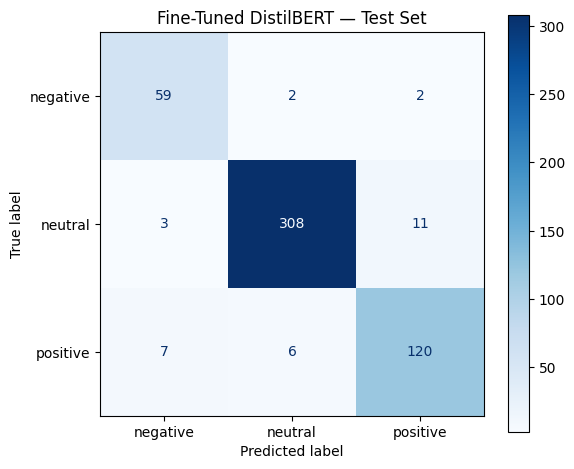

In [27]:
ft_test_preds = compute_predictions(
    trainer.model, ft_tokenizer, df_test, LABEL2ID, ID2LABEL
)

ft_test_metrics = evaluate_and_report(
    ft_test_preds,
    title='Fine-Tuned DistilBERT — Test Set',
    save_cm_path=os.path.join(FIG_DIR, 'confusion_matrix_test.png')
)

---
## 9. Export Per-Example Outputs

In [28]:
val_out = os.path.join(DATA_DIR, 'finetuned_distilbert_val_predictions.csv')
test_out = os.path.join(DATA_DIR, 'finetuned_distilbert_test_predictions.csv')

ft_val_preds.to_csv(val_out, index=False)
ft_test_preds.to_csv(test_out, index=False)

print(f'Saved: {val_out}')
print(f'Saved: {test_out}')
print(f'\nValidation predictions sample:')
ft_val_preds.head()

Saved: /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/processed_data/finetuned_distilbert_val_predictions.csv
Saved: /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/processed_data/finetuned_distilbert_test_predictions.csv

Validation predictions sample:


,id,sentence,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence,entropy,margin
0,432,The company recorded revenues of E658 .1 milli...,positive,positive,0.001474,0.001454,0.997072,0.997072,0.022032,0.995599
1,1005,Aspo has also investigated the sales opportuni...,neutral,neutral,0.000855,0.997180,0.001964,0.997180,0.021100,0.995216
2,3305,"In the fourth quarter of 2008 , net sales decr...",negative,negative,0.989785,0.006820,0.003396,0.989785,0.063485,0.982965
3,1090,The event can also be viewed as a live webcast...,neutral,neutral,0.000924,0.998167,0.000909,0.998167,0.014653,0.997243
4,2494,"Eero Katajavuori , currently Group Vice Presid...",neutral,neutral,0.000988,0.998221,0.000791,0.998221,0.014264,0.997233


In [29]:
print('Test predictions sample:')
ft_test_preds.head()

Test predictions sample:


,id,sentence,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence,entropy,margin
0,2033,Lemmink+ñinen started the manufacture of roofi...,neutral,neutral,0.000936,0.998234,0.000829,0.998234,0.014179,0.997298
1,2602,OP-Pohjola Group 's capital adequacy ratio und...,neutral,neutral,0.000764,0.998278,0.000958,0.998278,0.013862,0.997320
2,124,Also Lemmink+ñinen 's profit for accounting pe...,positive,positive,0.001344,0.001427,0.997229,0.997229,0.021005,0.995802
3,2306,The reductions will be implemented mainly in t...,neutral,neutral,0.001140,0.997993,0.000867,0.997993,0.015841,0.996854
4,2590,No planned closing date was provided .,neutral,neutral,0.001406,0.997726,0.000868,0.997726,0.017621,0.996320


---
## 10. Save Canonical Baseline Artifact

In [30]:
save_dir = os.path.join(MODEL_DIR, 'finetuned_distilbert_baseline')
os.makedirs(save_dir, exist_ok=True)

trainer.model.save_pretrained(save_dir)
ft_tokenizer.save_pretrained(save_dir)

training_config = {
    'base_model': 'distilbert-base-uncased',
    'num_labels': 3,
    'label2id': LABEL2ID,
    'max_len': MAX_LEN,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'warmup_ratio': WARMUP_RATIO,
    'early_stopping_patience': PATIENCE,
    'seed': SEED,
    'best_val_f1': trainer.state.best_metric,
    'val_metrics': ft_val_metrics,
    'test_metrics': ft_test_metrics,
}

config_path = os.path.join(save_dir, 'training_config.json')
with open(config_path, 'w') as f:
    json.dump(training_config, f, indent=2)

print(f'Model + tokenizer saved to: {save_dir}')
print(f'Training config saved to:   {config_path}')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.05it/s]

Model + tokenizer saved to: /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/models/finetuned_distilbert_baseline
Training config saved to:   /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/models/finetuned_distilbert_baseline/training_config.json


---
## 11. Summary Comparison

In [31]:
summary = pd.DataFrame([
    {'Model': 'DistilBERT (zero-shot)',  'Split': 'test', **distilbert_zs_metrics},
    {'Model': 'FinBERT (zero-shot)',     'Split': 'test', **finbert_metrics},
    {'Model': 'DistilBERT (fine-tuned)', 'Split': 'val',  **ft_val_metrics},
    {'Model': 'DistilBERT (fine-tuned)', 'Split': 'test', **ft_test_metrics},
])

summary['accuracy'] = summary['accuracy'].map('{:.4f}'.format)
summary['macro_f1'] = summary['macro_f1'].map('{:.4f}'.format)

print('\n' + '=' * 60)
print('  PHASE 1 — BASELINE SUMMARY')
print('=' * 60)
summary


  PHASE 1 — BASELINE SUMMARY


,Model,Split,accuracy,macro_f1
0,DistilBERT (zero-shot),test,0.2239,0.1732
1,FinBERT (zero-shot),test,0.9459,0.9346
2,DistilBERT (fine-tuned),val,0.9207,0.8976
3,DistilBERT (fine-tuned),test,0.9402,0.9206


In [32]:
print('\nAll artifacts saved to Google Drive:')
print(f'  {DATA_DIR}/baseline_distilbert_test_predictions.csv')
print(f'  {DATA_DIR}/baseline_finbert_test_predictions.csv')
print(f'  {DATA_DIR}/finetuned_distilbert_val_predictions.csv')
print(f'  {DATA_DIR}/finetuned_distilbert_test_predictions.csv')
print(f'  {save_dir}/ (model + tokenizer + config)')
print(f'  {FIG_DIR}/confusion_matrix_val.png')
print(f'  {FIG_DIR}/confusion_matrix_test.png')
print('\nPhase 1 complete.')


All artifacts saved to Google Drive:
  /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/processed_data/baseline_distilbert_test_predictions.csv
  /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/processed_data/baseline_finbert_test_predictions.csv
  /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/processed_data/finetuned_distilbert_val_predictions.csv
  /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/processed_data/finetuned_distilbert_test_predictions.csv
  /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/models/finetuned_distilbert_baseline/ (model + tokenizer + config)
  /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-awar